# 6CS012 – Artificial Intelligence and Machine Learning
## Worksheet - 1: Image Understanding and Compression with PCA
Name:Samir Gurung
UId: 2438443

## Step 0: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

RGB_IMAGE_PATH   = '/content/drive/MyDrive/DSC_0204.JPG'
GRAY_IMAGE_PATH  = '/content/drive/MyDrive/DSC_0204.JPG'
PCA_IMAGE_PATH   = '/content/drive/MyDrive/DSC_0204.JPG'

print("Drive mounted!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted!


## Install / Import Required Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


---
# Exercise 1 – RGB Image Processing
### Task 1.1 – Read and Display the Image

Image shape : (531, 413, 3)
Dtype       : uint8
Min / Max   : 0 / 255


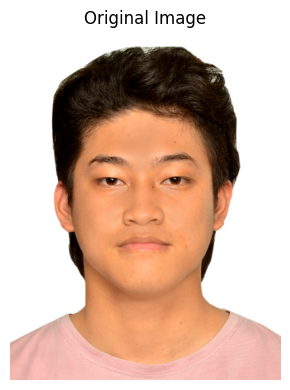

In [4]:
# ── Load image using Pillow ────────────────────────────────────────────────
img_pil  = Image.open(RGB_IMAGE_PATH).convert('RGB')
img_rgb  = np.array(img_pil)   # Convert to NumPy array  shape: (H, W, 3)

print(f"Image shape : {img_rgb.shape}")
print(f"Dtype       : {img_rgb.dtype}")
print(f"Min / Max   : {img_rgb.min()} / {img_rgb.max()}")

# ── Display ────────────────────────────────────────────────────────────────
plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.tight_layout()
plt.show()

### Task 1.2 – Display Top-Left 100×100 Pixels

Top-left crop shape: (100, 100, 3)


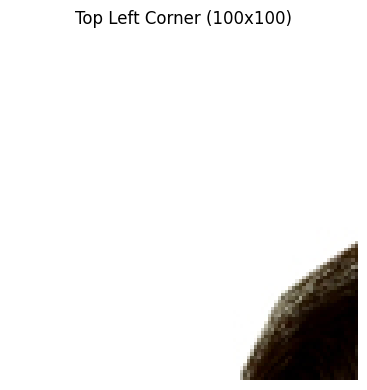

In [5]:
# Extract top-left 100x100 region using NumPy array indexing
top_left = img_rgb[:100, :100, :]   # rows 0-99, cols 0-99, all channels

print(f"Top-left crop shape: {top_left.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(top_left)
plt.title('Top Left Corner (100x100)')
plt.axis('off')
plt.tight_layout()
plt.show()

### Task 1.3 – Show Three Color Channels (R, G, B)

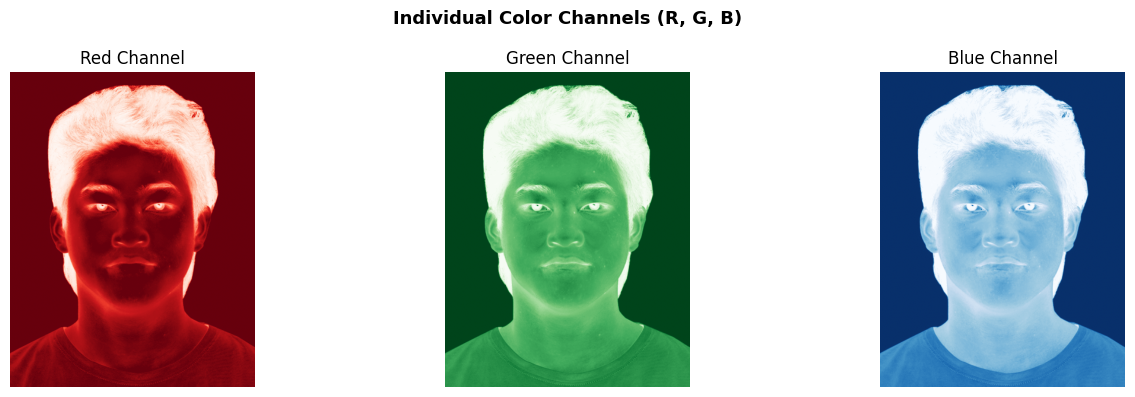

Note: The coloured backgrounds are due to matplotlib cmap argument.
PIL would display these in grayscale (intensity values only).


In [6]:
# Separate individual channels using NumPy
R = img_rgb[:, :, 0]   # Red channel
G = img_rgb[:, :, 1]   # Green channel
B = img_rgb[:, :, 2]   # Blue channel

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(R, cmap='Reds')
axes[0].set_title('Red Channel')
axes[0].axis('off')

axes[1].imshow(G, cmap='Greens')
axes[1].set_title('Green Channel')
axes[1].axis('off')

axes[2].imshow(B, cmap='Blues')
axes[2].set_title('Blue Channel')
axes[2].axis('off')

plt.suptitle('Individual Color Channels (R, G, B)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Note: The coloured backgrounds are due to matplotlib cmap argument.")
print("PIL would display these in grayscale (intensity values only).")

### Task 1.4 – Modify Top 100×100 Pixels to Value 210

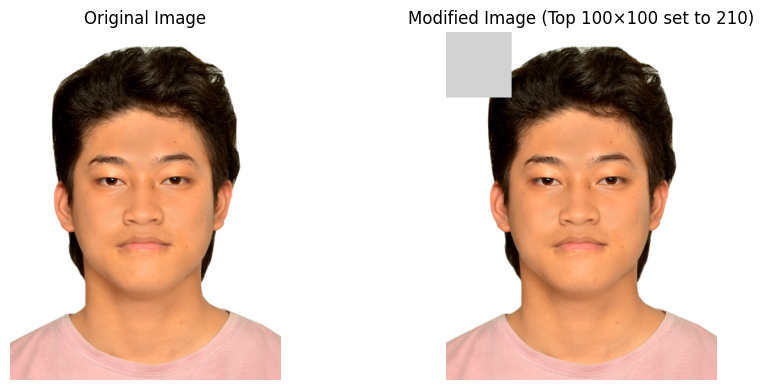

In [7]:
# Create a copy so we don't overwrite the original
img_modified = img_rgb.copy()

# Set the top-left 100x100 pixels to 210 (light grey)
img_modified[:100, :100, :] = 210

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_modified)
axes[1].set_title('Modified Image (Top 100×100 set to 210)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Exercise 1 – Combined Output (matching Figure 1 layout)

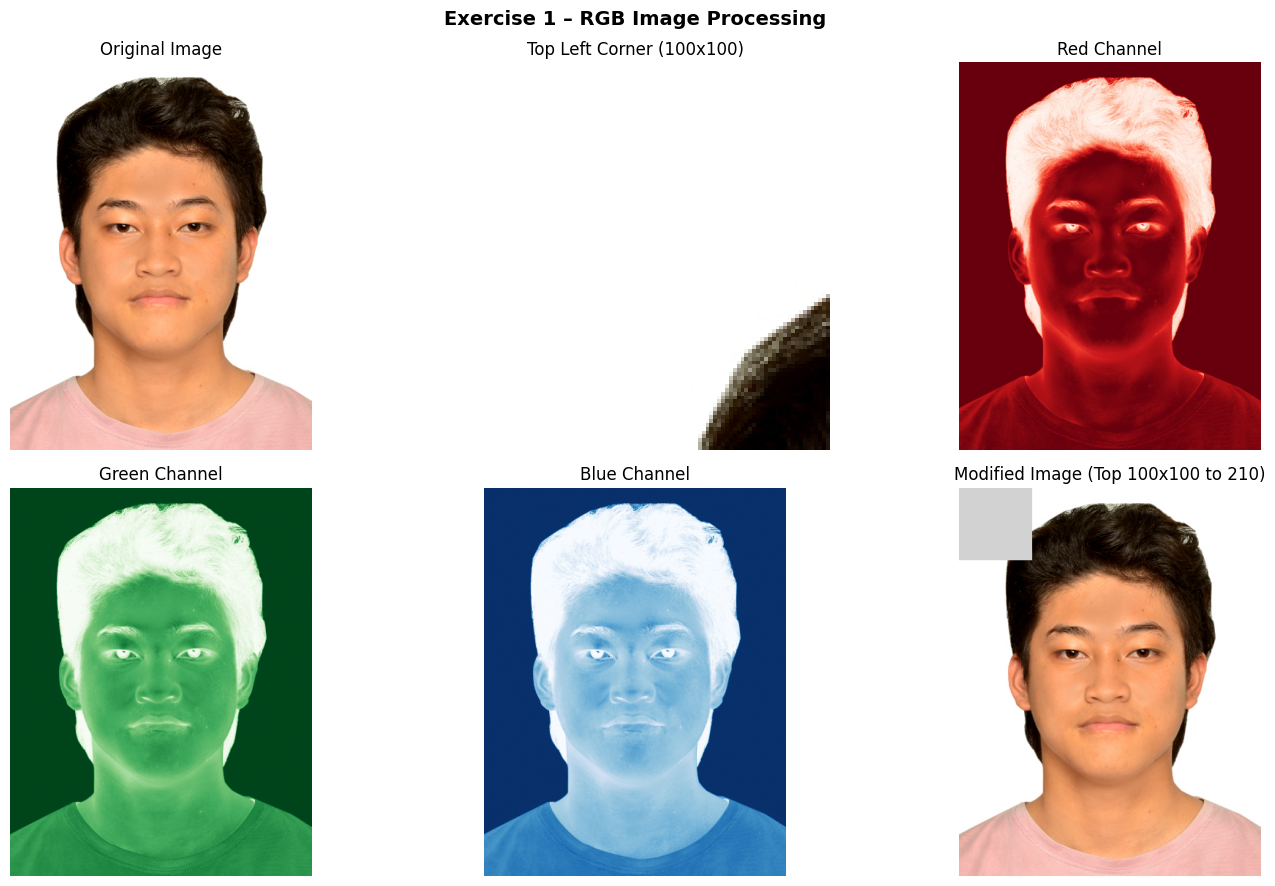

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(img_rgb);        axes[0, 0].set_title('Original Image');               axes[0, 0].axis('off')
axes[0, 1].imshow(top_left);       axes[0, 1].set_title('Top Left Corner (100x100)');    axes[0, 1].axis('off')
axes[0, 2].imshow(R, cmap='Reds'); axes[0, 2].set_title('Red Channel');                  axes[0, 2].axis('off')
axes[1, 0].imshow(G, cmap='Greens'); axes[1, 0].set_title('Green Channel');              axes[1, 0].axis('off')
axes[1, 1].imshow(B, cmap='Blues'); axes[1, 1].set_title('Blue Channel');                axes[1, 1].axis('off')
axes[1, 2].imshow(img_modified);   axes[1, 2].set_title('Modified Image (Top 100x100 to 210)'); axes[1, 2].axis('off')

plt.suptitle('Exercise 1 – RGB Image Processing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Exercise 2 – Grayscale Image Processing
### Task 2.1 – Load and Display a Grayscale Image

Grayscale image shape : (531, 413)
Dtype                 : uint8
Min / Max pixel       : 0 / 255


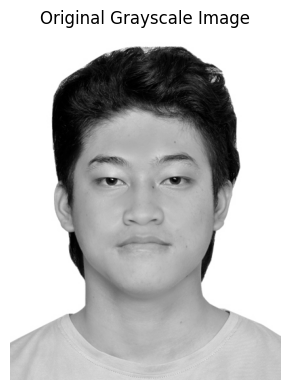

In [9]:
# Load image and convert to grayscale
gray_pil  = Image.open(GRAY_IMAGE_PATH).convert('L')   # 'L' = grayscale
gray_arr  = np.array(gray_pil)                          # shape: (H, W)

print(f"Grayscale image shape : {gray_arr.shape}")
print(f"Dtype                 : {gray_arr.dtype}")
print(f"Min / Max pixel       : {gray_arr.min()} / {gray_arr.max()}")

plt.figure(figsize=(4, 4))
plt.imshow(gray_arr, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.tight_layout()
plt.show()

### Task 2.2 – Extract Middle 150×150 Section

Middle section shape: (150, 150)


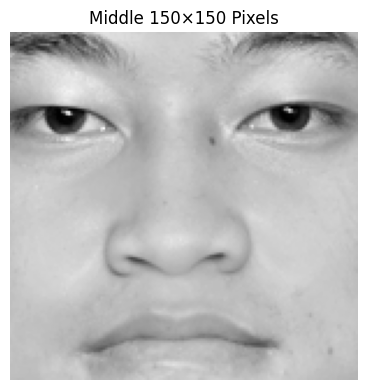

In [10]:
H, W = gray_arr.shape

# Calculate centre coordinates
cy, cx = H // 2, W // 2

# Extract 150-pixel section from the centre
mid_section = gray_arr[cy - 75 : cy + 75, cx - 75 : cx + 75]

print(f"Middle section shape: {mid_section.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(mid_section, cmap='gray')
plt.title('Middle 150×150 Pixels')
plt.axis('off')
plt.tight_layout()
plt.show()

### Task 2.3 – Apply Threshold (< 100 → 0, >= 100 → 255)

Unique values after thresholding: [  0 255]


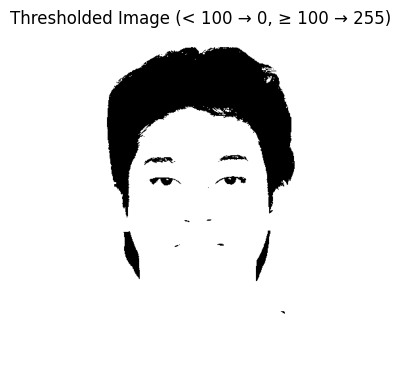

In [11]:
# Apply binary threshold
binary_img = np.where(gray_arr < 100, 0, 255).astype(np.uint8)

print(f"Unique values after thresholding: {np.unique(binary_img)}")

plt.figure(figsize=(4, 4))
plt.imshow(binary_img, cmap='gray')
plt.title('Thresholded Image (< 100 → 0, ≥ 100 → 255)')
plt.axis('off')
plt.tight_layout()
plt.show()

### Task 2.4 – Rotate Image 90° Clockwise

Rotated image shape: (413, 531)


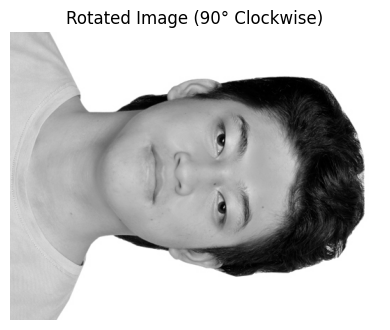

In [12]:
# Method 1: Using Pillow (rotate takes counter-clockwise angle, so use -90 for clockwise)
rotated_pil = gray_pil.rotate(-90, expand=True)
rotated_arr = np.array(rotated_pil)

# Method 2: Using NumPy (np.rot90 with k=-1 rotates 90° clockwise)
# rotated_arr = np.rot90(gray_arr, k=-1)

print(f"Rotated image shape: {rotated_arr.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(rotated_arr, cmap='gray')
plt.title('Rotated Image (90° Clockwise)')
plt.axis('off')
plt.tight_layout()
plt.show()

### Task 2.5 – Convert Grayscale to RGB

Converted RGB shape: (531, 413, 3)


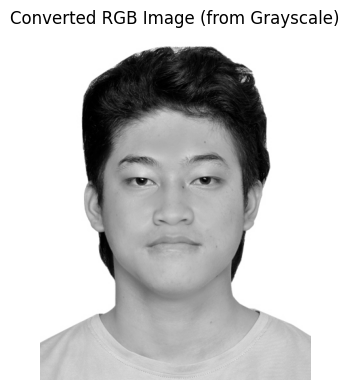

In [13]:
# Stack the single channel 3 times to create an RGB image
rgb_from_gray = np.stack([gray_arr, gray_arr, gray_arr], axis=-1)

print(f"Converted RGB shape: {rgb_from_gray.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(rgb_from_gray)
plt.title('Converted RGB Image (from Grayscale)')
plt.axis('off')
plt.tight_layout()
plt.show()

### Exercise 2 – Combined Output (matching Figure 2 layout)

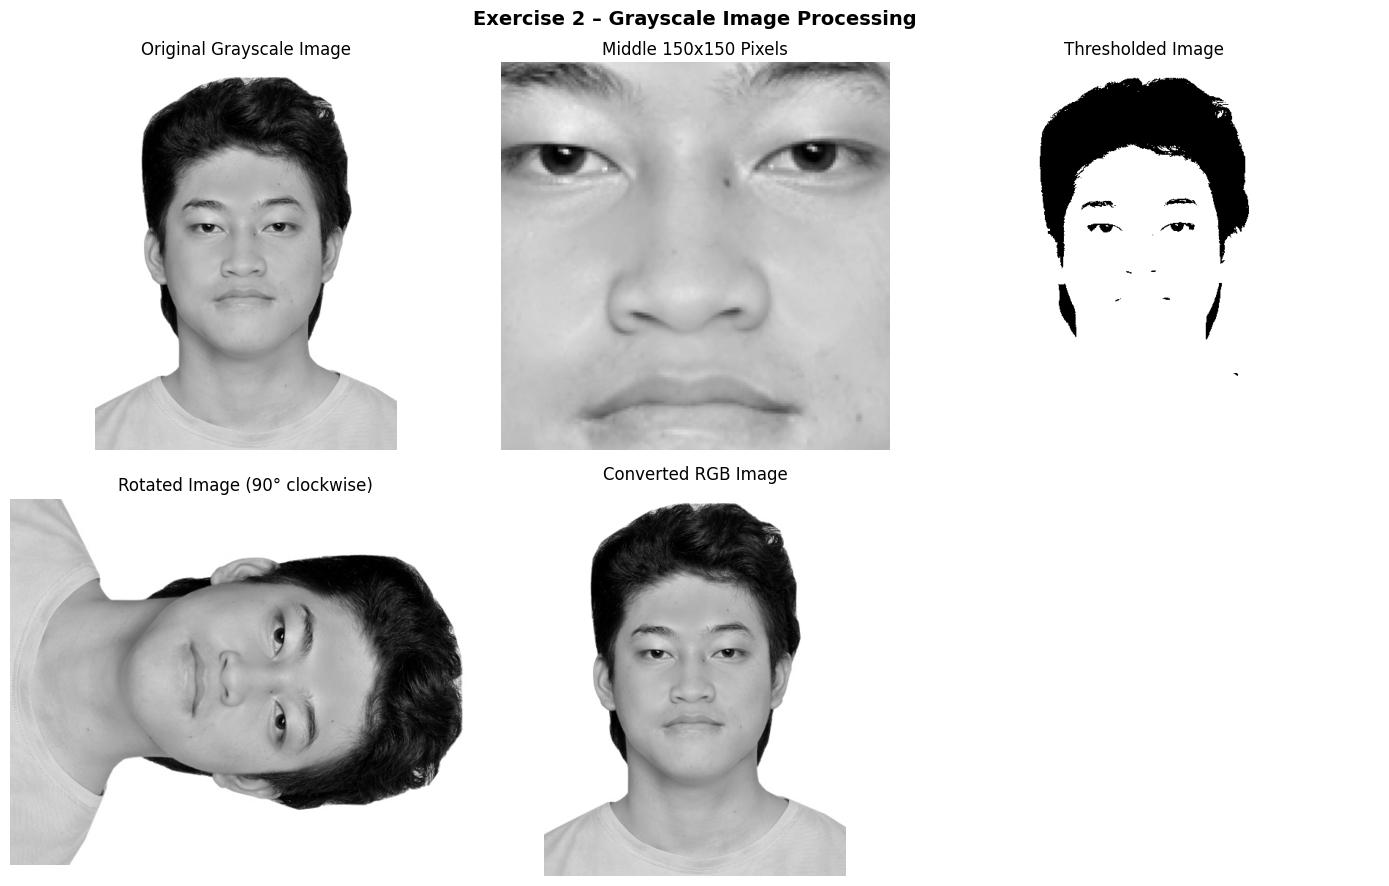

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(gray_arr,    cmap='gray'); axes[0, 0].set_title('Original Grayscale Image');          axes[0, 0].axis('off')
axes[0, 1].imshow(mid_section, cmap='gray'); axes[0, 1].set_title('Middle 150x150 Pixels');             axes[0, 1].axis('off')
axes[0, 2].imshow(binary_img,  cmap='gray'); axes[0, 2].set_title('Thresholded Image');                 axes[0, 2].axis('off')
axes[1, 0].imshow(rotated_arr, cmap='gray'); axes[1, 0].set_title('Rotated Image (90° clockwise)');     axes[1, 0].axis('off')
axes[1, 1].imshow(rgb_from_gray);            axes[1, 1].set_title('Converted RGB Image');               axes[1, 1].axis('off')
axes[1, 2].axis('off')  # empty cell

plt.suptitle('Exercise 2 – Grayscale Image Processing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Exercise 3 – PCA Image Compression from Scratch


### Step 3.1 – Load and Prepare Data

Image shape : (531, 413)
Min / Max   : 0.00 / 255.00


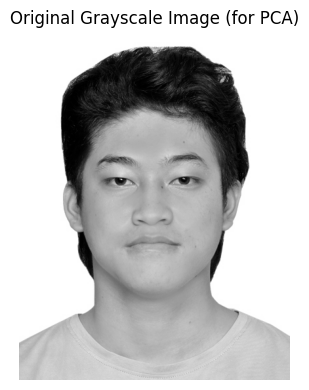

In [15]:
# Load image and convert to grayscale
pca_img_pil  = Image.open(PCA_IMAGE_PATH).convert('L')
pca_img      = np.array(pca_img_pil, dtype=np.float64)   # shape: (H, W)

print(f"Image shape : {pca_img.shape}")
print(f"Min / Max   : {pca_img.min():.2f} / {pca_img.max():.2f}")

plt.figure(figsize=(4, 4))
plt.imshow(pca_img, cmap='gray')
plt.title('Original Grayscale Image (for PCA)')
plt.axis('off')
plt.tight_layout()
plt.show()

### Step 3.2 – Centre (Standardise) the Data

In [16]:
# Each row is a pixel row; each column is a feature (pixel position)
# Centre by subtracting the mean of each column (feature)
mean_vec   = np.mean(pca_img, axis=0)      # shape: (W,)
X_centered = pca_img - mean_vec            # shape: (H, W)

print(f"Mean vector shape   : {mean_vec.shape}")
print(f"Centred data shape  : {X_centered.shape}")
print(f"Mean after centering: {X_centered.mean():.6f}  (should be ~0)")

Mean vector shape   : (413,)
Centred data shape  : (531, 413)
Mean after centering: -0.000000  (should be ~0)


### Step 3.3 – Compute the Covariance Matrix

In [17]:
n = X_centered.shape[0]   # number of rows (samples)

# Covariance matrix: C = (1/n) * X^T * X   shape: (W, W)
cov_matrix = (X_centered.T @ X_centered) / n

print(f"Covariance matrix shape: {cov_matrix.shape}")
print(f"Symmetric check (should be True): {np.allclose(cov_matrix, cov_matrix.T)}")

Covariance matrix shape: (413, 413)
Symmetric check (should be True): True


### Step 3.4 – Eigen Decomposition & Sort Principal Components

In [18]:
# Compute eigenvalues and eigenvectors from scratch using np.linalg.eigh
# eigh is used for symmetric/Hermitian matrices (faster + more stable than eig)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues in DESCENDING order
sorted_idx   = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print(f"Eigenvalues shape  : {eigenvalues.shape}")
print(f"Eigenvectors shape : {eigenvectors.shape}")
print(f"Top 5 eigenvalues  : {eigenvalues[:5]}")

Eigenvalues shape  : (413,)
Eigenvectors shape : (413, 413)
Top 5 eigenvalues  : [852303.85657307 479724.91302357 108858.18983789  62144.919726
  42509.44000287]


### Step 3.5 – Identify Principal Components via Cumulative Explained Variance

90% variance explained by 5 components
95% variance explained by 10 components
99% variance explained by 36 components


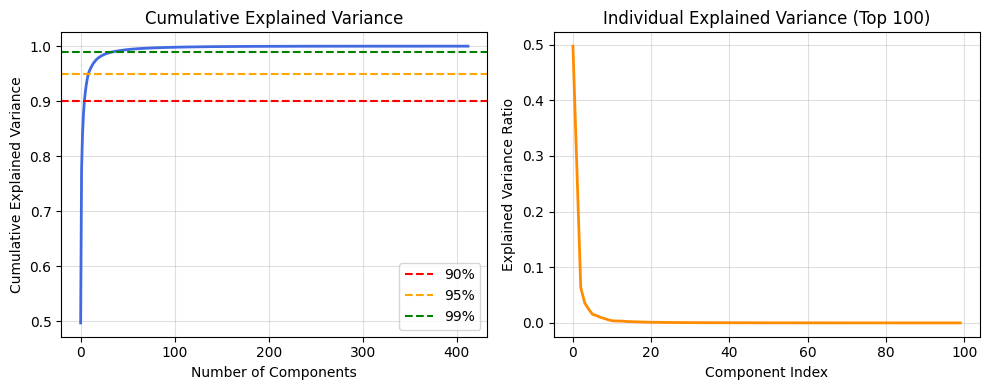

In [19]:
# Explained variance ratio
total_variance    = np.sum(eigenvalues)
explained_var     = eigenvalues / total_variance
cumulative_var    = np.cumsum(explained_var)

# Find how many components for 90%, 95%, 99% variance
for threshold in [0.90, 0.95, 0.99]:
    k = np.argmax(cumulative_var >= threshold) + 1
    print(f"{int(threshold*100)}% variance explained by {k} components")

# ── Plot cumulative explained variance ────────────────────────────────────
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(cumulative_var, color='royalblue', linewidth=2)
plt.axhline(y=0.90, color='red',    linestyle='--', label='90%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.axhline(y=0.99, color='green',  linestyle='--', label='99%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.4)

plt.subplot(1, 2, 2)
plt.plot(explained_var[:100], color='darkorange', linewidth=2)
plt.xlabel('Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance (Top 100)')
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Step 3.6 – PCA Helper Functions: Compress & Reconstruct

In [21]:
def pca_compress(X_centered, eigenvectors, k):
    """
    Project data onto the top-k principal components.

    Parameters:
        X_centered  : Centred data matrix of shape (H, W)
        eigenvectors: Eigenvector matrix of shape (W, W), sorted descending
        k           : Number of principal components to keep
    Returns:
        Z: Compressed representation of shape (H, k)
    """
    Vk = eigenvectors[:, :k]       # Top-k eigenvectors, shape (W, k)
    Z  = X_centered @ Vk           # Project, shape (H, k)
    return Z


def pca_reconstruct(Z, eigenvectors, k, mean_vec):
    """
    Reconstruct the image from compressed representation.

    Parameters:
        Z           : Compressed data of shape (H, k)
        eigenvectors: Eigenvector matrix of shape (W, W), sorted descending
        k           : Number of principal components used
        mean_vec    : Original column mean vector of shape (W,)
    Returns:
        Reconstructed image of shape (H, W), clipped to [0, 255]
    """
    Vk           = eigenvectors[:, :k]      # Top-k eigenvectors
    X_approx     = Z @ Vk.T                 # Back-project
    X_reconstructed = X_approx + mean_vec   # Add mean back
    return np.clip(X_reconstructed, 0, 255)


def explained_variance_k(eigenvalues, k):
    """Return the cumulative explained variance for k components."""
    return np.sum(eigenvalues[:k]) / np.sum(eigenvalues) * 100


print("PCA helper functions defined!")

PCA helper functions defined!


### Step 3.7 – Experiment: Reconstruct with k = 10, 20, 50, 100, 150 Components

In [22]:
k_values = [10, 20, 50, 100, 150]

reconstructed_images = {}
for k in k_values:
    Z    = pca_compress(X_centered, eigenvectors, k)
    recon = pca_reconstruct(Z, eigenvectors, k, mean_vec)
    ev   = explained_variance_k(eigenvalues, k)
    reconstructed_images[k] = (recon, ev)
    print(f"k = {k:4d} | Explained Variance: {ev:.2f}% | Compressed size: {Z.shape}")

k =   10 | Explained Variance: 95.38% | Compressed size: (531, 10)
k =   20 | Explained Variance: 97.89% | Compressed size: (531, 20)
k =   50 | Explained Variance: 99.36% | Compressed size: (531, 50)
k =  100 | Explained Variance: 99.80% | Compressed size: (531, 100)
k =  150 | Explained Variance: 99.93% | Compressed size: (531, 150)


### Step 3.8 – Display and Compare Results (matching Figure 3 layout)

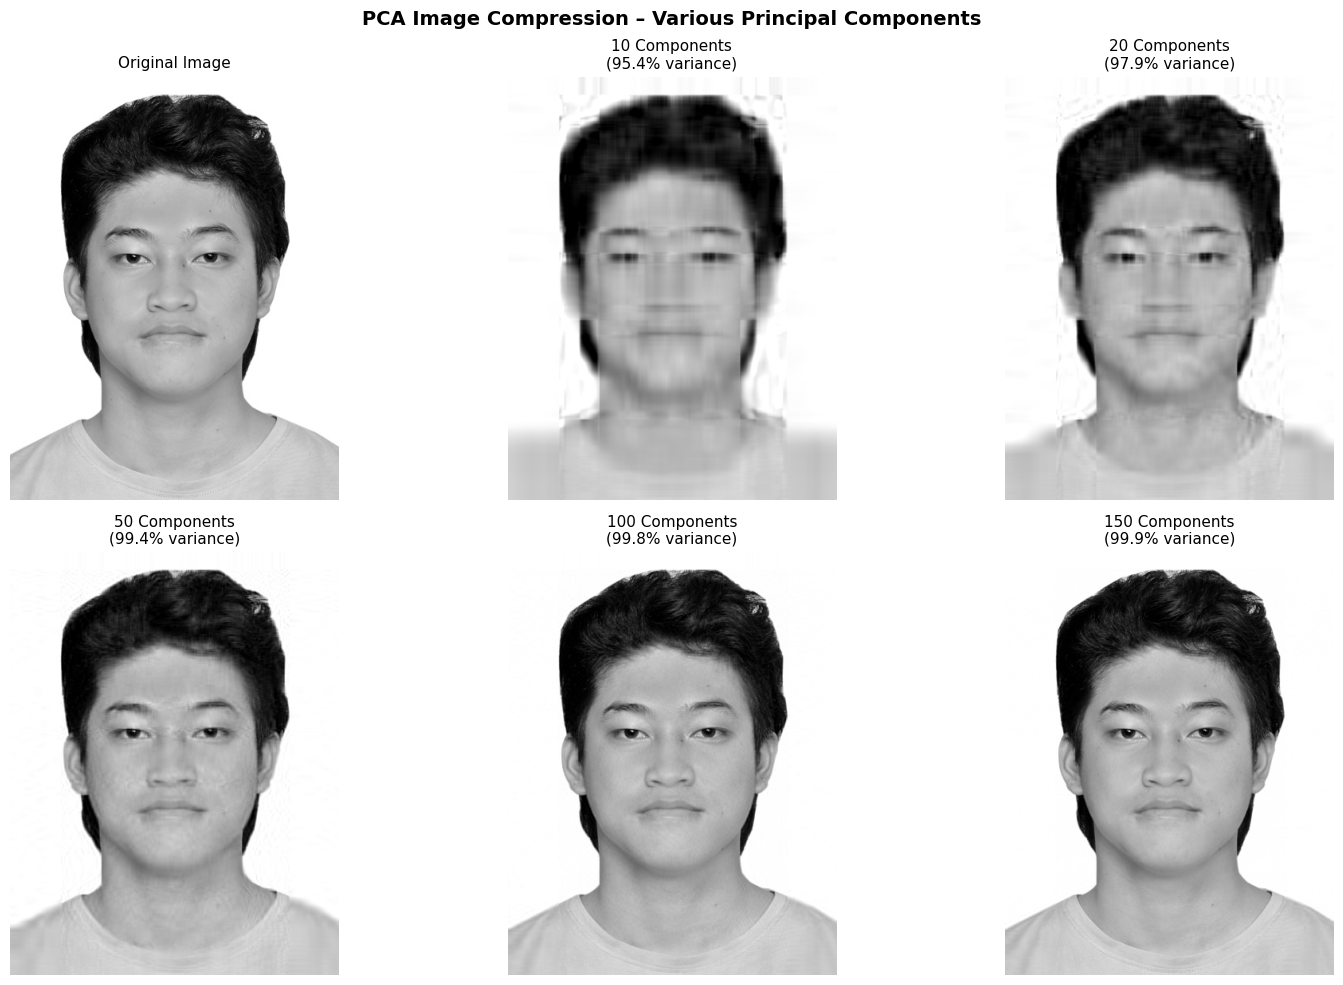

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Original
axes[0, 0].imshow(pca_img, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=11)
axes[0, 0].axis('off')

# Reconstructed images
positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
for idx, k in enumerate(k_values):
    r, c = positions[idx]
    recon, ev = reconstructed_images[k]
    axes[r, c].imshow(recon, cmap='gray')
    axes[r, c].set_title(f'{k} Components\n({ev:.1f}% variance)', fontsize=11)
    axes[r, c].axis('off')

plt.suptitle('PCA Image Compression – Various Principal Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3.9 – Evaluate Reconstruction Quality (MSE & PSNR)

In [24]:
def mse(original, reconstructed):
    """Mean Squared Error between original and reconstructed image."""
    return np.mean((original - reconstructed) ** 2)

def psnr(original, reconstructed, max_val=255.0):
    """Peak Signal-to-Noise Ratio (higher = better reconstruction)."""
    m = mse(original, reconstructed)
    if m == 0:
        return float('inf')
    return 20 * np.log10(max_val / np.sqrt(m))

print(f"{'k':>6} | {'Expl. Var (%)':>14} | {'MSE':>10} | {'PSNR (dB)':>10}")
print("-" * 50)
for k in k_values:
    recon, ev = reconstructed_images[k]
    m = mse(pca_img, recon)
    p = psnr(pca_img, recon)
    print(f"{k:>6} | {ev:>14.2f} | {m:>10.2f} | {p:>10.2f}")

     k |  Expl. Var (%) |        MSE |  PSNR (dB)
--------------------------------------------------
    10 |          95.38 |     180.71 |      25.56
    20 |          97.89 |      82.25 |      28.98
    50 |          99.36 |      25.05 |      34.14
   100 |          99.80 |       7.63 |      39.30
   150 |          99.93 |       2.79 |      43.68


### Step 3.10 – Compression Ratio Analysis

In [25]:
H_img, W_img = pca_img.shape
original_size = H_img * W_img

print(f"Original image pixels: {original_size:,}  ({H_img} x {W_img})\n")
print(f"{'k':>6} | {'Compressed Size':>16} | {'Compression Ratio':>18}")
print("-" * 48)
for k in k_values:
    # Compressed = projection matrix Z (H x k) + eigenvectors (W x k) + mean (W,)
    compressed_size = H_img * k + W_img * k + W_img
    ratio = original_size / compressed_size
    print(f"{k:>6} | {compressed_size:>16,} | {ratio:>18.2f}x")

Original image pixels: 219,303  (531 x 413)

     k |  Compressed Size |  Compression Ratio
------------------------------------------------
    10 |            9,853 |              22.26x
    20 |           19,293 |              11.37x
    50 |           47,613 |               4.61x
   100 |           94,813 |               2.31x
   150 |          142,013 |               1.54x
